# 6. Mehanizam potpornih vektora (SVM)

## Osnovna ideja

Support Vector Machine traži razdvajajuću **hiperravan** koja **maksimizuje marginu**
između dve klase.

$$w \cdot x + b = 0$$

| pojam | značenje |
|---|---|
| **hiperravan** | prava u 2D, ravan u 3D, hiperravan u $n$D |
| **margina** | maksimalni razmak između klasa |
| **potporni vektori** | tačke koje dodiruju margine |

Vektor $w$ je **perpendikularan** na hiperravan i određuje njen pravac. Znak izraza
$w \cdot x + b$ pokazuje na kojoj strani se nalazi tačka:

- $w \cdot x + b > 0$ → jedna klasa
- $w \cdot x + b < 0$ → druga klasa

> Postoji **beskonačno mnogo** hiperravni koje razdvajaju podatke. SVM bira onu sa
> **najvećom marginom**, jer veća margina znači bolju generalizaciju na nove podatke.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.datasets import make_blobs, make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42

X, y = make_blobs(n_samples=60, centers=2, cluster_std=1.1, random_state=6)
print(f"Podaci: {X.shape[0]} uzoraka, 2 obelezja, 2 klase (linearno separabilne)")

Podaci: 60 uzoraka, 2 obelezja, 2 klase (linearno separabilne)


## Uslovi za pravilnu klasifikaciju

Za tačke pozitivne klase: $w \cdot x_i + b \geq 1$
Za tačke negativne klase: $w \cdot x_i + b \leq -1$

Uvođenjem $y_i \in \{+1, -1\}$ oba uslova se spajaju u **jedan**:

$$y_i \, (w \cdot x_i + b) \geq 1$$

## Izračunavanje margine

Za potporne vektore važi $w \cdot x^+ + b = +1$ i $w \cdot x^- + b = -1$. Oduzimanjem:

$$w \cdot x^+ - w \cdot x^- = 2$$

Projekcija razlike na jedinični vektor $\frac{w}{\lVert w \rVert}$ daje širinu margine:

$$\boxed{\text{margina} = \frac{2}{\lVert w \rVert}}$$

Odatle sledi ključni zaključak:

$$\text{maksimizovati marginu} \iff \text{minimizovati } \lVert w \rVert$$

## Optimizacioni problem

$$\min \lVert w \rVert \quad \text{uz ograničenje} \quad y_i(w \cdot x_i + b) \geq 1$$

Rešava se **Lagrangeovim multiplikatorima**:

$$L = \tfrac{1}{2}\lVert w \rVert^2 - \sum_i \alpha_i \big[ y_i (w \cdot x_i + b) - 1 \big]$$

Iz uslova optimalnosti:

$$\frac{\partial L}{\partial w} = 0 \implies w = \sum_i \alpha_i y_i x_i \qquad
\frac{\partial L}{\partial b} = 0 \implies \sum_i \alpha_i y_i = 0$$

> **Ključna posledica:** $w$ je linearna kombinacija trening tačaka, ali **samo one sa
> $\alpha_i > 0$ učestvuju** — to su **potporni vektori**. Većina tačaka ne utiče na rešenje.

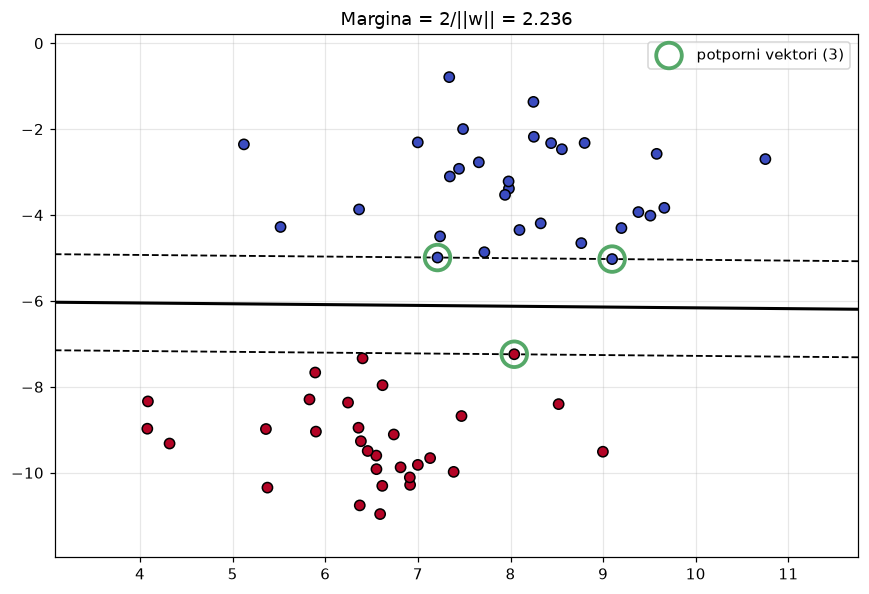

w = [-0.0168 -0.8943],  b = -5.3411
||w|| = 0.8944   ->   margina = 2/||w|| = 2.2361

Trening tacaka: 60, potpornih vektora: 3
-> Hiperravan odredjuje samo 3 tacaka, ostale ne uticu.


In [2]:
svm = SVC(kernel="linear", C=1000).fit(X, y)      # veliko C ~ tvrda margina

w, b = svm.coef_[0], svm.intercept_[0]
margina = 2 / np.linalg.norm(w)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(X[:, 0], X[:, 1], c=y, s=45, cmap="coolwarm", edgecolor="k", zorder=3)

xl = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 50)
yl = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 50)
YY, XX = np.meshgrid(yl, xl)
Z = svm.decision_function(np.vstack([XX.ravel(), YY.ravel()]).T).reshape(XX.shape)
ax.contour(XX, YY, Z, colors="k", levels=[-1, 0, 1],
           linestyles=["--", "-", "--"], linewidths=[1.2, 2, 1.2])

ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
           s=280, facecolors="none", edgecolors="#55A868", linewidths=2.5,
           label=f"potporni vektori ({len(svm.support_vectors_)})", zorder=4)
ax.set_title(f"Margina = 2/||w|| = {margina:.3f}"); ax.legend()
plt.tight_layout(); plt.show()

print(f"w = {w.round(4)},  b = {b:.4f}")
print(f"||w|| = {np.linalg.norm(w):.4f}   ->   margina = 2/||w|| = {margina:.4f}")
print(f"\nTrening tacaka: {len(X)}, potpornih vektora: {len(svm.support_vectors_)}")
print(f"-> Hiperravan odredjuje samo {len(svm.support_vectors_)} tacaka, ostale ne uticu.")

In [3]:
# dokaz: uklonimo tacku koja NIJE potporni vektor -> resenje se ne menja
nije_sv = [i for i in range(len(X)) if i not in svm.support_]
maska = np.ones(len(X), bool); maska[nije_sv[0]] = False

svm2 = SVC(kernel="linear", C=1000).fit(X[maska], y[maska])
print(f"Original bez izmene : w = {svm.coef_[0].round(5)}, b = {svm.intercept_[0]:.5f}")
print(f"Bez jedne NE-SV tacke: w = {svm2.coef_[0].round(5)}, b = {svm2.intercept_[0]:.5f}")
print("-> Identicno. Tacke koje nisu potporni vektori se mogu izbaciti bez posledica.")

Original bez izmene : w = [-0.01682 -0.89426], b = -5.34113
Bez jedne NE-SV tacke: w = [-0.01682 -0.89426], b = -5.34113
-> Identicno. Tacke koje nisu potporni vektori se mogu izbaciti bez posledica.


## Klasifikacija nove tačke

Za novu, nepoznatu tačku $u$:

$$f(u) = \sum_i \alpha_i y_i (x_i \cdot u) + b$$

- $f(u) \geq 0$ → pozitivna klasa
- $f(u) < 0$ → negativna klasa

Računa se **skalarni proizvod** između potpornih vektora $x_i$ i nove tačke $u$.
Ovaj oblik je važan — u njemu se pojavljuje **samo skalarni proizvod**, što će omogućiti
kernel trik.

## Parametar C — meka margina

U praksi podaci retko dozvoljavaju savršeno razdvajanje. Parametar $C$ kontroliše koliko
se kažnjava ulazak tačaka u marginu:

| $C$ | margina | ponašanje |
|---|---|---|
| **malo** | široka | dozvoljava greške, jednostavnija granica, veći bias |
| **veliko** | uska | pokušava savršeno razdvajanje, rizik od overfittinga |

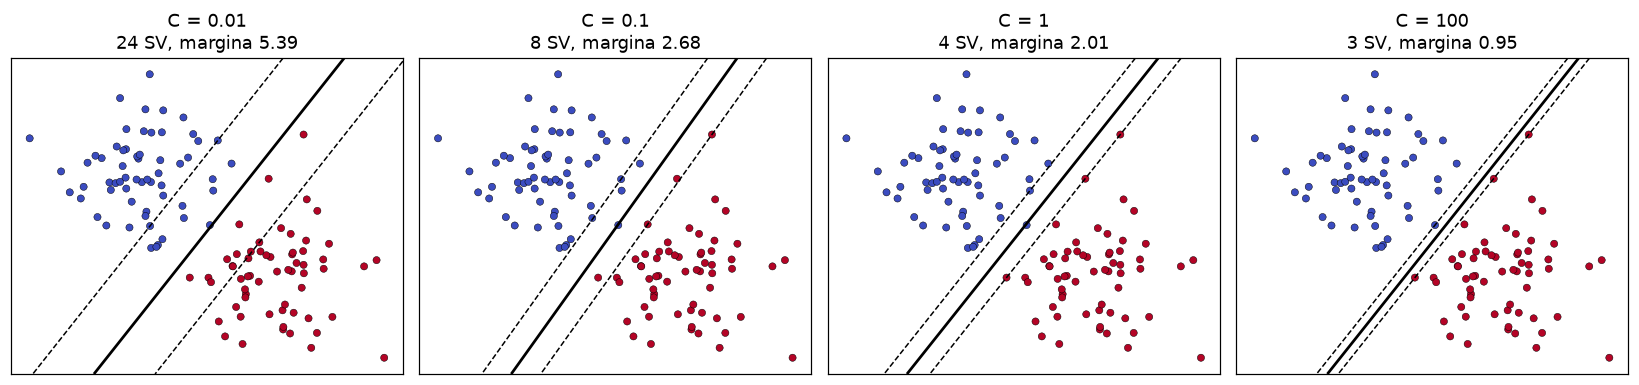

Malo C -> siroka margina, mnogo potpornih vektora, jednostavniji model.


In [4]:
Xm, ym = make_blobs(n_samples=120, centers=2, cluster_std=2.4, random_state=RS)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, Cv in zip(ax, (0.01, 0.1, 1, 100)):
    m = SVC(kernel="linear", C=Cv).fit(Xm, ym)
    a.scatter(Xm[:, 0], Xm[:, 1], c=ym, s=22, cmap="coolwarm", edgecolor="k", linewidth=0.3)
    x0, x1 = Xm[:, 0].min()-1, Xm[:, 0].max()+1
    y0, y1 = Xm[:, 1].min()-1, Xm[:, 1].max()+1
    XX, YY = np.meshgrid(np.linspace(x0, x1, 60), np.linspace(y0, y1, 60))
    Z = m.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    a.contour(XX, YY, Z, colors="k", levels=[-1, 0, 1], linestyles=["--","-","--"], linewidths=[1,1.8,1])
    a.set_title(f"C = {Cv}\n{len(m.support_)} SV, margina {2/np.linalg.norm(m.coef_[0]):.2f}")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Malo C -> siroka margina, mnogo potpornih vektora, jednostavniji model.")

## Nelinearno separabilni problemi — XOR

Osnovni (linearni) SVM radi **samo** za linearno separabilne podatke. Klasičan
kontraprimer je **XOR**:

- pozitivna klasa: $(0,0)$ i $(1,1)$
- negativna klasa: $(0,1)$ i $(1,0)$

Ne postoji prava koja razdvaja klase — bez obzira kako je povučemo, uvek greši.

> **Poruka:** problem nije u algoritmu, nego u **prostoru u kome gledamo podatke**.
> Ako promenimo perspektivu, ono što je bilo nelinearno može postati linearno.
> **Ne menjamo algoritam — menjamo prostor.**

XOR — linearni kernel: tacnost 0.50   <- ne moze
XOR — RBF kernel     : tacnost 1.00   <- resava


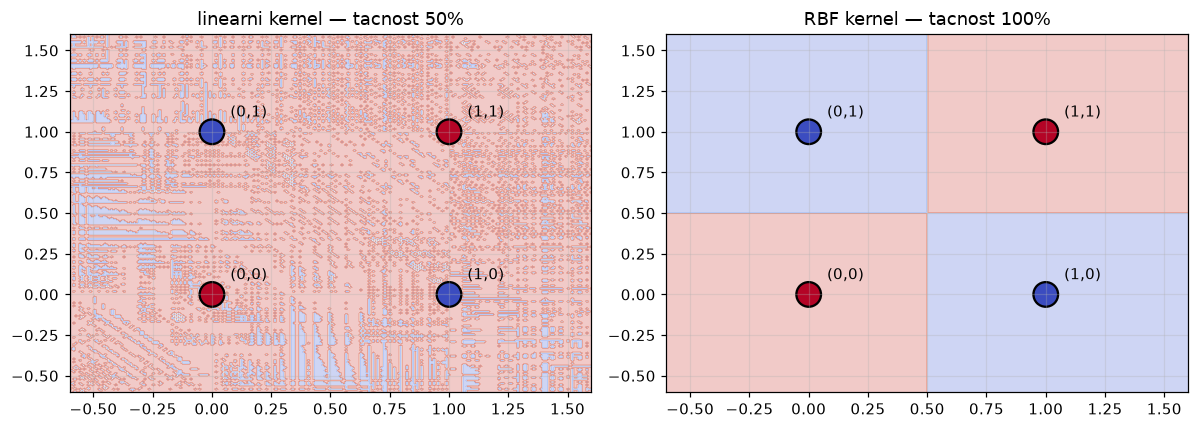

In [5]:
Xx = np.array([[0,0],[1,1],[0,1],[1,0]], float)
yx = np.array([1, 1, 0, 0])

lin = SVC(kernel="linear", C=100).fit(Xx, yx)
rbf = SVC(kernel="rbf", C=100, gamma=2).fit(Xx, yx)
print(f"XOR — linearni kernel: tacnost {lin.score(Xx, yx):.2f}   <- ne moze")
print(f"XOR — RBF kernel     : tacnost {rbf.score(Xx, yx):.2f}   <- resava")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (m, ime) in zip(ax, [(lin, "linearni kernel"), (rbf, "RBF kernel")]):
    XX, YY = np.meshgrid(np.linspace(-0.6, 1.6, 250), np.linspace(-0.6, 1.6, 250))
    Z = m.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    a.contourf(XX, YY, Z, alpha=0.28, cmap="coolwarm")
    a.scatter(Xx[:, 0], Xx[:, 1], c=yx, s=260, cmap="coolwarm", edgecolor="k", linewidth=1.5)
    for (px, py), kl in zip(Xx, yx):
        a.annotate(f"({px:.0f},{py:.0f})", (px, py), textcoords="offset points",
                   xytext=(12, 10), fontsize=10)
    a.set_title(f"{ime} — tacnost {m.score(Xx, yx):.0%}")
plt.tight_layout(); plt.show()

## Kernel trik

**Pretpostavka:** postoji transformacija $T(x)$ koja preslikava podatke u
višedimenzionalni prostor gde je linearno razdvajanje moguće.

**Problem:** u decision function bi trebalo računati $T(x_i) \cdot T(u)$, a to je računski
vrlo skupo (ili nemoguće ako je dimenzionalnost beskonačna).

**Rešenje — kernel funkcija:**

$$K(x_i, u) = T(x_i) \cdot T(u)$$

Kernel **direktno računa skalarni proizvod u višedimenzionalnom prostoru**, bez potrebe da
poznajemo ili računamo samu transformaciju $T$.

> SVM i dalje ostaje **linearan** — ali u novom prostoru osobina.
> Kernel funkcije se mogu tumačiti kao **mere sličnosti** između podataka.

### Popularne kernel funkcije

| kernel | formula |
|---|---|
| **linearni** | $K(u,v) = u \cdot v$ |
| **polinomijalni** | $K(u,v) = (u \cdot v + 1)^n$ |
| **Gaussov (RBF)** | $K(u,v) = \exp\left(-\dfrac{\lVert u-v \rVert^2}{2\sigma^2}\right)$ |

U `scikit-learn` se RBF piše kao $\exp(-\gamma \lVert u-v \rVert^2)$, gde je
$\gamma = \frac{1}{2\sigma^2}$.

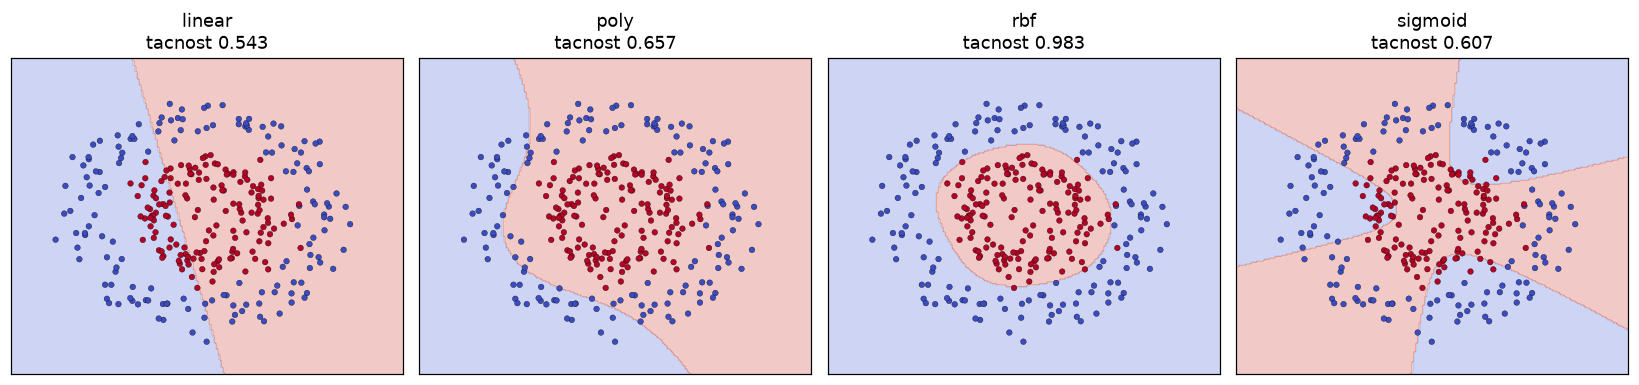

Podaci su koncentricni krugovi — linearni kernel nema sanse, RBF ih razdvaja lako.


In [6]:
Xc, yc = make_circles(n_samples=300, factor=0.45, noise=0.12, random_state=RS)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, (k, par) in zip(ax, [("linear", {}), ("poly", {"degree": 3}),
                            ("rbf", {"gamma": 1}), ("sigmoid", {})]):
    m = make_pipeline(StandardScaler(), SVC(kernel=k, C=1, **par)).fit(Xc, yc)
    XX, YY = np.meshgrid(np.linspace(-1.6, 1.6, 220), np.linspace(-1.6, 1.6, 220))
    Z = m.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    a.contourf(XX, YY, Z, alpha=0.28, cmap="coolwarm")
    a.scatter(Xc[:, 0], Xc[:, 1], c=yc, s=14, cmap="coolwarm", edgecolor="k", linewidth=0.2)
    a.set_title(f"{k}\ntacnost {m.score(Xc, yc):.3f}"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Podaci su koncentricni krugovi — linearni kernel nema sanse, RBF ih razdvaja lako.")

### Uticaj parametra $\gamma$ kod RBF kernela

$\gamma$ određuje koliko „daleko" seže uticaj jedne trening tačke:

- **malo $\gamma$** — širok uticaj, glatka granica, rizik od underfittinga
- **veliko $\gamma$** — uzak uticaj, granica se lepi za pojedinačne tačke, overfitting

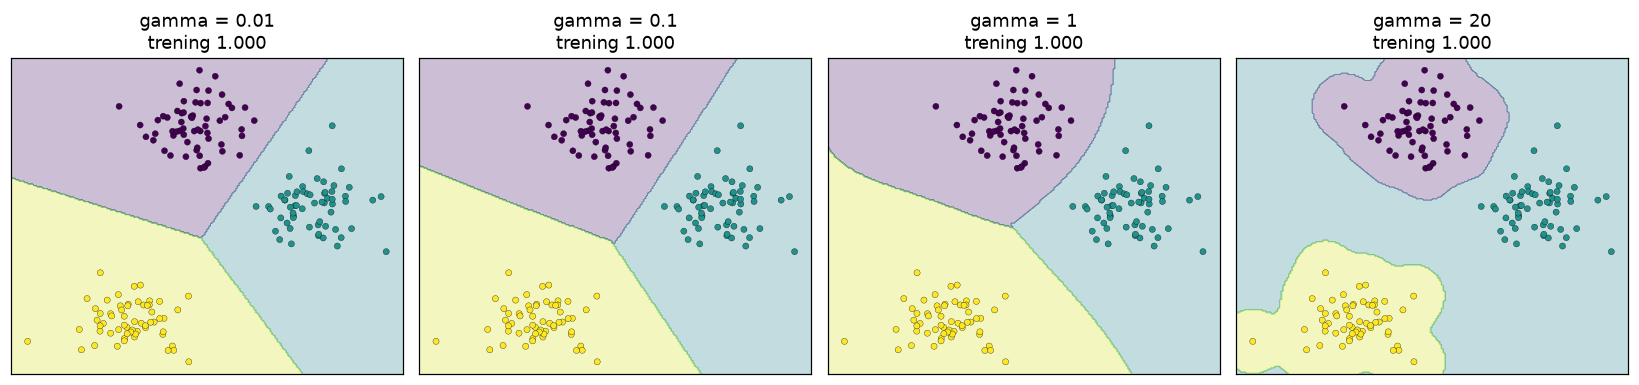

In [7]:
Xg, yg = make_blobs(n_samples=180, centers=3, cluster_std=1.8, random_state=RS)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, g in zip(ax, (0.01, 0.1, 1, 20)):
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=g)).fit(Xg, yg)
    XX, YY = np.meshgrid(np.linspace(Xg[:,0].min()-1, Xg[:,0].max()+1, 220),
                         np.linspace(Xg[:,1].min()-1, Xg[:,1].max()+1, 220))
    Z = m.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    a.contourf(XX, YY, Z, alpha=0.28, cmap="viridis")
    a.scatter(Xg[:,0], Xg[:,1], c=yg, s=16, cmap="viridis", edgecolor="k", linewidth=0.2)
    a.set_title(f"gamma = {g}\ntrening {m.score(Xg, yg):.3f}")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## SVM u praksi

**Skaliranje je obavezno** — SVM se oslanja na rastojanja i skalarne proizvode, pa
atributi sa velikim vrednostima dominiraju.

Dva hiperparametra se podešavaju zajedno: **`C`** i **`gamma`**.

In [8]:
bc = load_breast_cancer()
Xb, yb = bc.data, bc.target

bez = cross_val_score(SVC(kernel="rbf"), Xb, yb, cv=5).mean()
sa = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf")), Xb, yb, cv=5).mean()
print(f"BEZ skaliranja: {bez:.4f}")
print(f"SA skaliranjem: {sa:.4f}   <- razlika je velika\n")

gs = GridSearchCV(Pipeline([("sc", StandardScaler()), ("svm", SVC())]),
                  {"svm__C": [0.1, 1, 10, 100],
                   "svm__gamma": ["scale", 0.001, 0.01, 0.1],
                   "svm__kernel": ["rbf", "linear"]},
                  cv=5, n_jobs=-1).fit(Xb, yb)
print(f"Najbolji parametri: {gs.best_params_}")
print(f"Najbolji CV rezultat: {gs.best_score_:.4f}")

BEZ skaliranja: 0.9122
SA skaliranjem: 0.9736   <- razlika je velika



Najbolji parametri: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Najbolji CV rezultat: 0.9789


## Ograničenja i sažetak

**Ograničenja osnovnog SVM-a**
- definisan za **binarnu** klasifikaciju (višeklasni se rešava strategijama one-vs-one / one-vs-rest)
- linearni oblik radi samo za **linearno separabilne** podatke — otud kernel trik
- složenost treniranja raste **kvadratno** sa brojem uzoraka, pa je spor na velikim skupovima
- ne daje prirodno verovatnoće (potreban `probability=True`, koji dodatno usporava)

**Prednosti**
- jasna geometrijska interpretacija i teorijska garancija (maksimalna margina)
- efikasan u **visokodimenzionalnim** prostorima
- rešenje zavisi samo od potpornih vektora, pa je memorijski štedljiv